# IO Pset 3 - Aunisha Saha

### Setup

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('rust_data_2020.csv')
df = df.sort_values(['bus_id', 'period_id']).reset_index(drop=True)

## Part 0

### Q1

In [4]:
# compute next period mileage and decision within each bus
df['x_next'] = df.groupby('bus_id')['x_it'].shift(-1)
df['y_next'] = df.groupby('bus_id')['y_it'].shift(-1)

# only look at periods where the engine was kept (y=0)
df0 = df[df['y_it'] == 0].copy()
df0 = df0.dropna(subset=['x_next', 'y_next'])

# mileage increase depends on what happens next period:
# if next period is a keep delta is the normal difference
# if next period is a replacement mileage resets so delta is just x_next
df0['delta_x'] = np.where(
    df0['y_next'] == 0,
    df0['x_next'] - df0['x_it'],
    df0['x_next']
).astype(int)

# include 4 even if not observed
p_delta = (df0['delta_x'].value_counts(normalize=True)
           .reindex([0, 1, 2, 3, 4], fill_value=0)
            .sort_index()
)

print('Transition probabilities: ')
print(p_delta)
print(f'\nSum = {p_delta.sum():.6f}')

Transition probabilities: 
0    0.089072
1    0.437134
2    0.463200
3    0.010594
4    0.000000
Name: delta_x, dtype: float64

Sum = 1.000000


### Q2

In [5]:
# states 0 to 200
x_states = 201
F = np.zeros((x_states, x_states))

# for each possible increment shift probability mass along the diagonal
# mileage is absorbed at the upper boundary (state 200)
for delta, prob in p_delta.items():
    d = int(delta)
    for x in range(x_states):
        F[x, min(x + d, x_states - 1)] += prob

# normalize rows so they sum to 1
F = F / F.sum(axis=1, keepdims=True)

print(f'all rows sum to 1: {np.allclose(F.sum(axis=1), 1.0)}')

all rows sum to 1: True


## Part 1

In [6]:
import scipy.optimize
from scipy.optimize import minimize

# discount factor
B = 0.975  
N = 201
x_vals = np.arange(N)

### Q1

In [7]:
def compute_ev(theta, tpm, x_vals, beta=B, tol=1e-6):
    # assign parameters
    a, b, RC = theta
    
    # quadratic maintenance cost
    # replacing costs RC and resets state to 0
    u_keep    = -(a * x_vals + b * x_vals**2)
    u_replace = -RC
    
    # start at EV=0 and iterate bellman until convergence
    EV = np.zeros(len(x_vals))
    
    while True:
        # choice specific value functions
        v_keep    = u_keep + beta * EV
        v_replace = u_replace + beta * EV[0]   # replacement always goes to state 0
        
        # emax = log(exp(v_keep) + exp(v_replace)) integrated over next state
        EV_new = tpm @ np.logaddexp(v_keep, v_replace)
        
        if np.max(np.abs(EV_new - EV)) < tol:
            return EV_new
        EV = EV_new

### Q2

In [8]:
def compute_ccp(theta, EV, x_vals, beta=B):
    a, b, RC = theta
    
    # quadratic cost
    u_keep    = -(a * x_vals + b * x_vals**2)
    u_replace = -RC

    v_keep    = u_keep + beta * EV
    v_replace = u_replace + beta * EV[0]
    
    # to avoid overflow
    log_p_keep = v_keep - np.logaddexp(v_keep, v_replace)
    return np.exp(log_p_keep)

### Q3

In [9]:
def nll(theta, x_obs, y_obs, tpm, x_vals):
    
    # solve EV fixed point for given theta
    EV = compute_ev(theta, tpm, x_vals)
    
    # get Prob of keep given x for all states
    p_keep = compute_ccp(theta, EV, x_vals)
    
    #clip to avoid log(0)
    p_keep = np.clip(p_keep, 1e-12, 1-1e-12)
    
    # log likelihood
    ll = np.where(y_obs==0, np.log(p_keep[x_obs]), np.log(1-p_keep[x_obs]))
    
    return -np.sum(ll)

### Q4

In [11]:
# the decision at time t is based on mileage at the start of the period
# but x_it records mileage after the period so we use the lagged value
df['x_lag'] = df.groupby('bus_id')['x_it'].shift(1)
df_model = df.dropna(subset=['x_lag'])

x_obs = df_model['x_lag'].values.astype(int)
y_obs = df_model['y_it'].values.astype(int)

# initial guess
theta0 = np.array([0.1, 0.001, 5.0])   

result = minimize(
    fun=nll,
    x0=theta0,
    args=(x_obs, y_obs, F, x_vals),
    method='L-BFGS-B',
    jac=False,
    bounds=[(1e-8, None), (0, None), (1e-6, None)],
    options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-7}
)

a_hat, b_hat, RC_hat = result.x
print(f'a  (linear cost)    = {a_hat:.6f}')
print(f'b  (quadratic cost) = {b_hat:.6f}')
print(f'RC (replacement)    = {RC_hat:.6f}')
print(f'Log-L               = {-result.fun:.4f}')
print(f'Converged           : {result.success}')

a  (linear cost)    = 0.027033
b  (quadratic cost) = 0.000022
RC (replacement)    = 12.329273
Log-L               = -861.9589
Converged           : True


## Graphs for sanity check

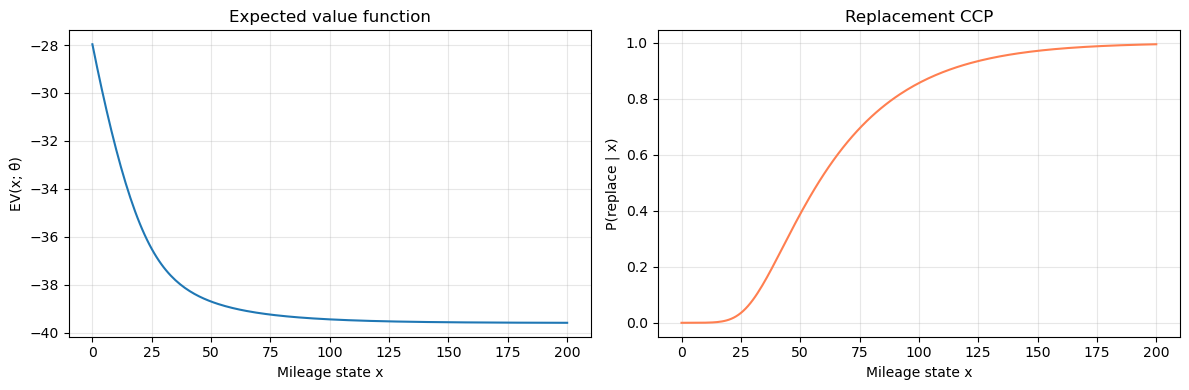

In [12]:
import matplotlib.pyplot as plt

EV_hat = compute_ev(result.x, F, x_vals)
p_rep  = 1 - compute_ccp(result.x, EV_hat, x_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_vals, EV_hat)
axes[0].set_xlabel('Mileage state x')
axes[0].set_ylabel('EV(x; θ̂)')
axes[0].set_title('Expected value function')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_vals, p_rep, color='coral')
axes[1].set_xlabel('Mileage state x')
axes[1].set_ylabel('P(replace | x)')
axes[1].set_title('Replacement CCP')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()